In [2]:
import requests
import pandas as pd
import time
import re
from datetime import datetime

# **Settings**

In [7]:
#TOKEN = ""
TOKEN = ""
# Famous public repositories:
REPOS = [
    "tensorflow/tensorflow",
    "pytorch/pytorch",
    "microsoft/vscode",
    "facebook/react",
    "scikit-learn/scikit-learn",
    "kubernetes-client/python",
    "NousResearch/hermes-agent",
    "pingcap/tidb",
    "multica-ai/multica",
    "rustfs/rustfs",
    "django/django",
    "pallets/flask",
    "apache/airflow",
    "electron/electron",
    "ansible/ansible",
    "moby/moby",
    "langchain-ai/langchain",
    "Significant-Gravitas/AutoGPT",
    "OpenInterpreter/open-interpreter",
    "deepset-ai/haystack"
]

COMMITS_PER_REPO = 500

BUG_WORDS = [
    "fix", "fixed", "fixes",
    "bug", "bugs",
    "error", "errors",
    "defect", "defects",
    "issue", "issues",
    "patch", "patched",
    "resolve", "resolved", "resolves",
    "hotfix"
]

HEADERS = {
    "Accept": "application/vnd.github+json",
    "Authorization": f"token {TOKEN}"
}

# **Helper Functions**

In [8]:
def is_bug_fix_message(message):
    message = message.lower()
    for word in BUG_WORDS:
        if word in message:
            return 1
    return 0


def github_get(url, params=None):
    response = requests.get(url, headers=HEADERS, params=params)

    # success
    if response.status_code == 200:
        return response.json()

    # rate limit or temporary block
    if response.status_code in [403, 429]:
        print("Rate limit hit. Sleeping for 60 seconds...")
        time.sleep(60)
        response = requests.get(url, headers=HEADERS, params=params)
        if response.status_code == 200:
            return response.json()

    print("Error:", response.status_code, url)
    return None


def get_commit_list(repo, total_commits):
    all_commits = []
    per_page = 100
    pages = (total_commits + per_page - 1) // per_page

    for page in range(1, pages + 1):
        url = f"https://api.github.com/repos/{repo}/commits"
        params = {"per_page": per_page, "page": page}
        data = github_get(url, params=params)

        if not data:
            break

        all_commits.extend(data)

        if len(data) < per_page:
            break

        time.sleep(0.2)

    return all_commits[:total_commits]


def get_commit_details(repo, sha):
    url = f"https://api.github.com/repos/{repo}/commits/{sha}"
    data = github_get(url)
    time.sleep(0.2)
    return data

# **Collect data**

In [9]:
all_rows = []

for repo in REPOS:
    print(f"\nCollecting from {repo} ...")

    commit_list = get_commit_list(repo, COMMITS_PER_REPO)
    repo_rows = []

    for i, item in enumerate(commit_list):
        sha = item["sha"]
        detail = get_commit_details(repo, sha)

        if detail is None:
            continue

        commit_info = detail.get("commit", {})
        author_info = commit_info.get("author", {}) or {}
        stats = detail.get("stats", {}) or {}
        parents = detail.get("parents", []) or []
        files = detail.get("files", []) or []

        message = commit_info.get("message", "") or ""
        author_name = author_info.get("name", "")
        author_date = author_info.get("date", "")

        parent_sha = parents[0]["sha"] if len(parents) > 0 else None

        changed_files = []
        for f in files:
            name = f.get("filename", "")
            if name:
                changed_files.append(name)

        row = {
            "repo": repo,
            "sha": sha,
            "parent_sha": parent_sha,
            "parent_count": len(parents),
            "author_name": author_name,
            "author_date": author_date,
            "message": message.replace("\n", " ").strip(),
            "files_changed": len(changed_files),
            "additions": stats.get("additions", 0),
            "deletions": stats.get("deletions", 0),
            "total_changes": stats.get("total", 0),
            "is_fix_commit": is_bug_fix_message(message)
        }

        repo_rows.append(row)

        if (i + 1) % 50 == 0:
            print(f"{repo}: {i+1} commits done")

    # parent labeling
    fix_parent_shas = set()
    for row in repo_rows:
        if row["is_fix_commit"] == 1 and row["parent_sha"] is not None:
            fix_parent_shas.add(row["parent_sha"])

    for row in repo_rows:
        row["buggy_label"] = 1 if row["sha"] in fix_parent_shas else 0

    all_rows.extend(repo_rows)

print("\nFinished collecting raw data.")


tensorflow/tensorflow: 50 commits done
tensorflow/tensorflow: 100 commits done
tensorflow/tensorflow: 150 commits done
tensorflow/tensorflow: 200 commits done
tensorflow/tensorflow: 250 commits done
tensorflow/tensorflow: 300 commits done
tensorflow/tensorflow: 350 commits done
tensorflow/tensorflow: 400 commits done
tensorflow/tensorflow: 450 commits done
tensorflow/tensorflow: 500 commits done

pytorch/pytorch: 50 commits done
pytorch/pytorch: 100 commits done
pytorch/pytorch: 150 commits done
pytorch/pytorch: 200 commits done
pytorch/pytorch: 250 commits done
pytorch/pytorch: 300 commits done
pytorch/pytorch: 350 commits done
pytorch/pytorch: 400 commits done
pytorch/pytorch: 450 commits done
pytorch/pytorch: 500 commits done

microsoft/vscode: 50 commits done
microsoft/vscode: 100 commits done
microsoft/vscode: 150 commits done
microsoft/vscode: 200 commits done
microsoft/vscode: 250 commits done
microsoft/vscode: 300 commits done
microsoft/vscode: 350 commits done
microsoft/vscod

# **Save CSV**

In [10]:
df_raw = pd.DataFrame(all_rows)
print(df_raw.shape)
df_raw.head()

(9985, 13)


,repo,sha,parent_sha,parent_count,author_name,author_date,message,files_changed,additions,deletions,total_changes,is_fix_commit,buggy_label
0,tensorflow/tensorflow,6fdd92a19642ade16dac69238096ae02ccbaa11d,25821c1ae79073fbecab46b2ecb2f349d99140dc,1,Alexander Belyaev,2026-04-12T10:25:29Z,[XLA:GPU] Use a map from the parallel dim id t...,8,109,43,152,0,0
1,tensorflow/tensorflow,25821c1ae79073fbecab46b2ecb2f349d99140dc,f93564545e21173ea11f0a84537698ff65aa7474,1,A. Unique TensorFlower,2026-04-11T17:08:02Z,Reverts 7baf72cd5425d5f24c737f4379957eb0deb712...,1,1,1,2,0,0
2,tensorflow/tensorflow,f93564545e21173ea11f0a84537698ff65aa7474,701380fcf4daab3480586274885496d62c4627eb,1,A. Unique TensorFlower,2026-04-11T08:07:17Z,Automated Code Change PiperOrigin-RevId: 8980...,1,3,2,5,0,0
3,tensorflow/tensorflow,701380fcf4daab3480586274885496d62c4627eb,48156b4934dceff5c931fb19569b4093b8272b3c,1,A. Unique TensorFlower,2026-04-11T07:25:39Z,Automated Code Change PiperOrigin-RevId: 8980...,9,9,0,9,0,0
4,tensorflow/tensorflow,48156b4934dceff5c931fb19569b4093b8272b3c,2b976f75daf37a27af68982b35cb625854579d88,1,A. Unique TensorFlower,2026-04-11T06:42:17Z,Automated Code Change PiperOrigin-RevId: 8980...,1,1,1,2,0,0


In [11]:
df_raw.to_csv("bug_prediction_raw_dataset.csv", index=False)
print("Saved: bug_prediction_raw_dataset.csv")

Saved: bug_prediction_raw_dataset.csv


In [3]:
df = pd.read_csv("bug_prediction_raw_dataset.csv")

In [4]:
df = df.drop(['repo','sha','parent_sha','author_name','author_date'], axis=1)

In [5]:
df.isnull().sum()

parent_count     0
message          0
files_changed    0
additions        0
deletions        0
total_changes    0
is_fix_commit    0
buggy_label      0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df['buggy_label'].value_counts()

buggy_label
0    5439
1    4546
Name: count, dtype: int64

In [8]:
df['buggy_label'].value_counts(normalize=True)

buggy_label
0    0.544717
1    0.455283
Name: proportion, dtype: float64

In [9]:
df.dtypes

parent_count      int64
message          object
files_changed     int64
additions         int64
deletions         int64
total_changes     int64
is_fix_commit     int64
buggy_label       int64
dtype: object

In [10]:
df.describe()

,parent_count,files_changed,additions,deletions,total_changes,is_fix_commit,buggy_label
count,9985.000000,9985.000000,9.985000e+03,9985.000000,9.985000e+03,9985.000000,9985.000000
mean,1.096144,7.499950,9.813349e+02,342.642364,1.323977e+03,0.474011,0.455283
std,0.294804,27.287624,2.796818e+04,9546.527784,2.993976e+04,0.499349,0.498021
min,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,1.000000,1.000000,5.000000e+00,1.000000,9.000000e+00,0.000000,0.000000
50%,1.000000,2.000000,2.600000e+01,6.000000,4.000000e+01,0.000000,0.000000
75%,1.000000,5.000000,1.160000e+02,29.000000,1.650000e+02,1.000000,1.000000
max,2.000000,300.000000,1.386698e+06,820147.000000,1.394819e+06,1.000000,1.000000


1. DATASET SHAPE
(9985, 13)

2. FIRST 5 ROWS
                    repo                                       sha  \
0  tensorflow/tensorflow  6fdd92a19642ade16dac69238096ae02ccbaa11d   
1  tensorflow/tensorflow  25821c1ae79073fbecab46b2ecb2f349d99140dc   
2  tensorflow/tensorflow  f93564545e21173ea11f0a84537698ff65aa7474   
3  tensorflow/tensorflow  701380fcf4daab3480586274885496d62c4627eb   
4  tensorflow/tensorflow  48156b4934dceff5c931fb19569b4093b8272b3c   

                                 parent_sha  parent_count  \
0  25821c1ae79073fbecab46b2ecb2f349d99140dc             1   
1  f93564545e21173ea11f0a84537698ff65aa7474             1   
2  701380fcf4daab3480586274885496d62c4627eb             1   
3  48156b4934dceff5c931fb19569b4093b8272b3c             1   
4  2b976f75daf37a27af68982b35cb625854579d88             1   

              author_name           author_date  \
0       Alexander Belyaev  2026-04-12T10:25:29Z   
1  A. Unique TensorFlower  2026-04-11T17:08:02Z   
2  A. Unique T

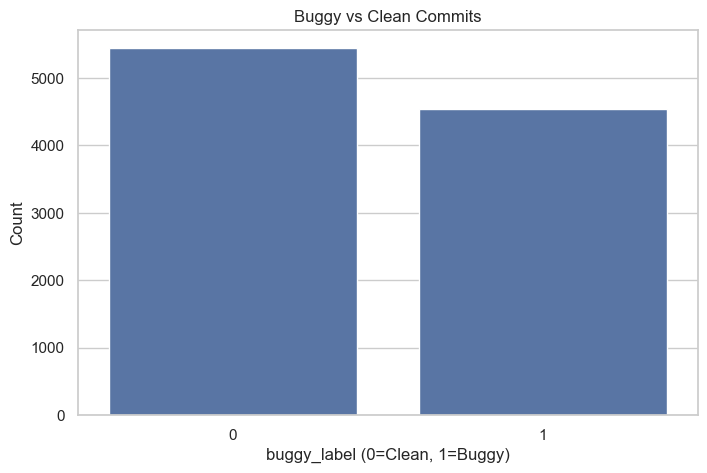

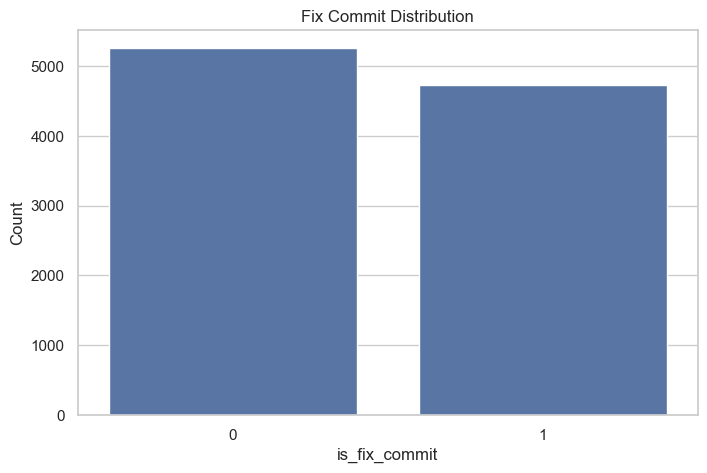

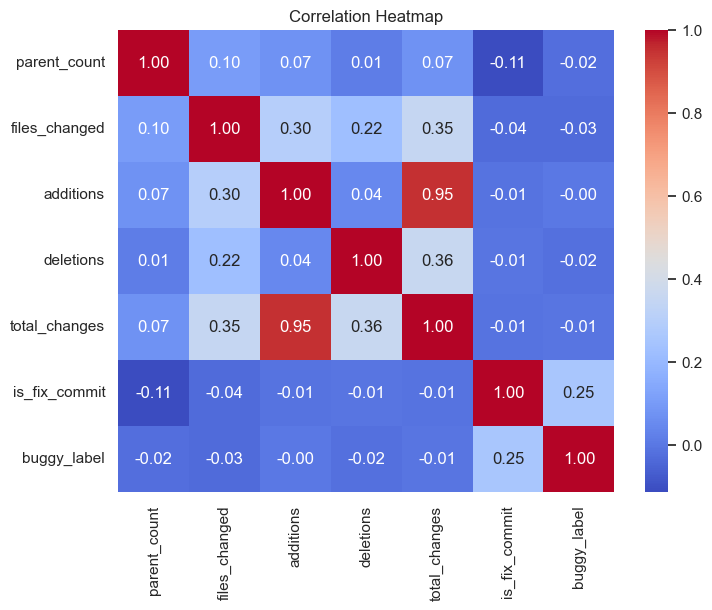

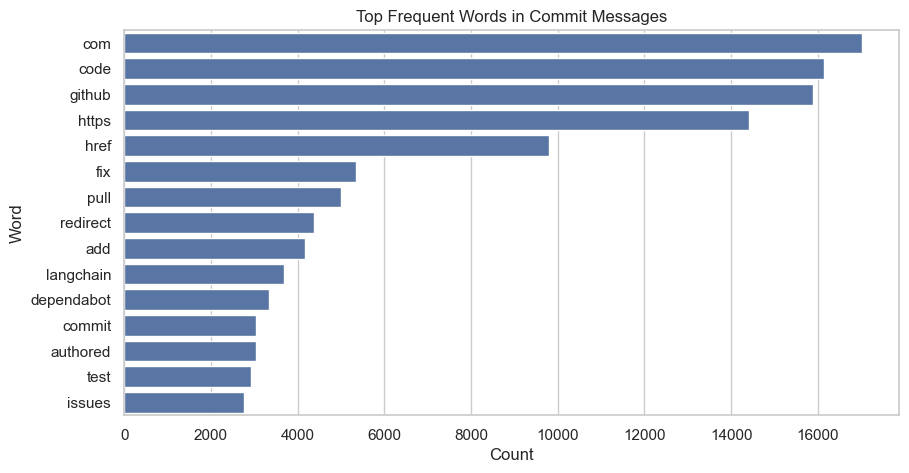


EDA COMPLETE

Key Insights:
1. Dataset is clean (no missing values).
2. Classes are nearly balanced.
3. Numeric features are right-skewed.
4. Several outliers exist.
5. total_changes strongly correlates with additions/deletions.
6. Dataset is ready for preprocessing and model training.



In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import pandas as pd
import time
import re
from datetime import datetime
# Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

df = pd.read_csv("bug_prediction_raw_dataset.csv")

print("="*50)
print("1. DATASET SHAPE")
print("="*50)
print(df.shape)

print("\n" + "="*50)
print("2. FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("3. DATASET INFO")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("4. MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("5. DUPLICATES")
print("="*50)
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "="*50)
print("6. STATISTICAL SUMMARY")
print("="*50)
print(df.describe())


plt.figure()
sns.countplot(x='buggy_label', data=df)
plt.title("Buggy vs Clean Commits")
plt.xlabel("buggy_label (0=Clean, 1=Buggy)")
plt.ylabel("Count")
plt.show()

plt.figure()
sns.countplot(x='is_fix_commit', data=df)
plt.title("Fix Commit Distribution")
plt.xlabel("is_fix_commit")
plt.ylabel("Count")
plt.show()



plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


from collections import Counter
import re

all_text = " ".join(df['message'].astype(str)).lower()
words = re.findall(r'\b[a-z]+\b', all_text)

stop_words = {
    'the','and','to','of','in','for','on','a','is','with',
    'this','that','it','at','by','an','be','from','or'
}

words = [w for w in words if w not in stop_words and len(w) > 2]

common_words = Counter(words).most_common(15)

word_df = pd.DataFrame(common_words, columns=['Word','Count'])

plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Word', data=word_df)
plt.title("Top Frequent Words in Commit Messages")
plt.show()


print("\n" + "="*50)
print("EDA COMPLETE")
print("="*50)
print("""
Key Insights:
1. Dataset is clean (no missing values).
2. Classes are nearly balanced.
3. Numeric features are right-skewed.
4. Several outliers exist.
5. total_changes strongly correlates with additions/deletions.
6. Dataset is ready for preprocessing and model training.
""")

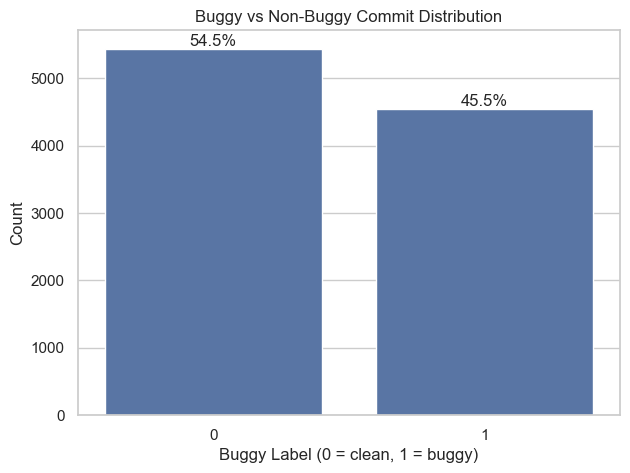

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

ax = sns.countplot(x="buggy_label", data=df)

# add percentages on top of bars
total = len(df)

for p in ax.patches:
    count = p.get_height()
    percentage = (count / total) * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom')

plt.title("Buggy vs Non-Buggy Commit Distribution")
plt.xlabel("Buggy Label (0 = clean, 1 = buggy)")
plt.ylabel("Count")

plt.show()

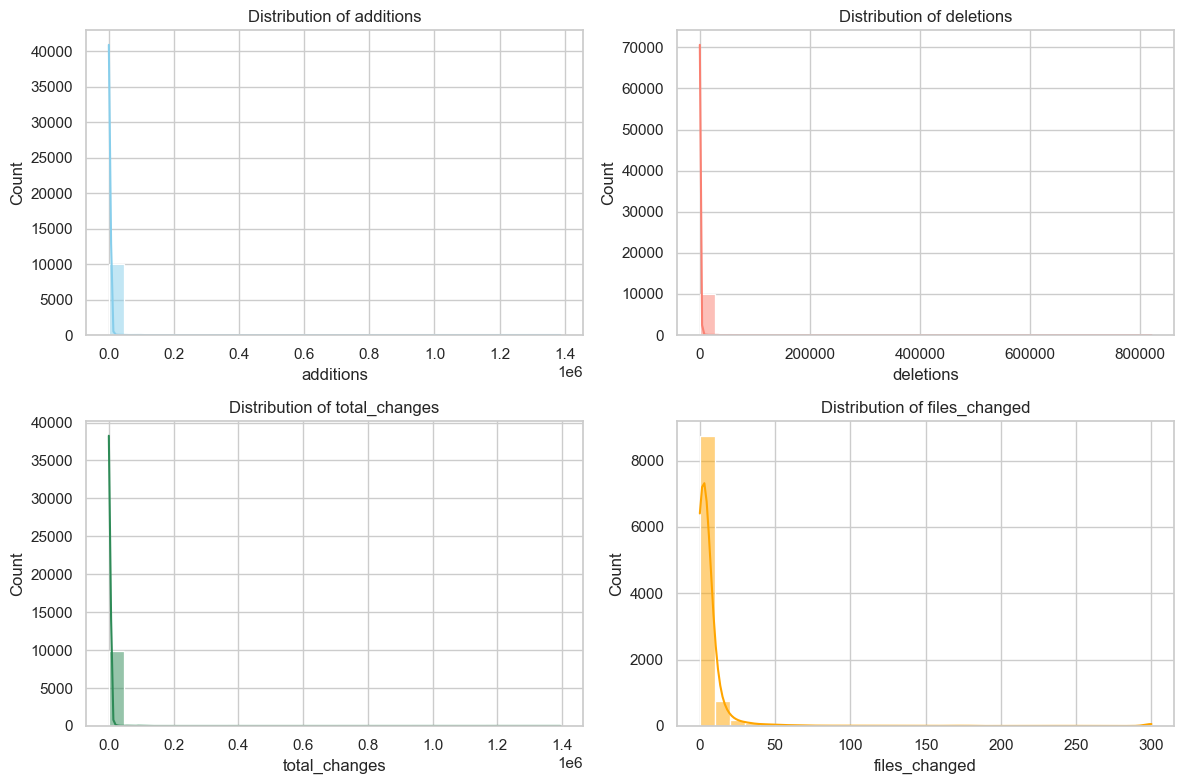

In [17]:
features = ["additions", "deletions", "total_changes", "files_changed"]

colors = ["skyblue", "salmon", "seagreen", "orange"]

plt.figure(figsize=(12,8))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], bins=30, kde=True, color=colors[i])
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [16]:
features = ["additions", "deletions", "total_changes", "files_changed"]

summary = df[features].describe().T
summary["median"] = df[features].median()
summary["skewness"] = df[features].skew()

summary

,count,mean,std,min,25%,50%,75%,max,median,skewness
additions,9985.0,981.334902,27968.175451,0.0,5.0,26.0,116.0,1386698.0,26.0,47.911507
deletions,9985.0,342.642364,9546.527784,0.0,1.0,6.0,29.0,820147.0,6.0,73.272699
total_changes,9985.0,1323.977266,29939.762749,0.0,9.0,40.0,165.0,1394819.0,40.0,42.212974
files_changed,9985.0,7.499950,27.287624,0.0,1.0,2.0,5.0,300.0,2.0,9.072953
